In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
%%capture
!pip -q install lightning torchinfo

## Import Module

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

# 실습 : CNN Feature Maps

## **DataSet**

In [4]:
from torchvision.datasets import FashionMNIST, MNIST

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True) ] )

epochs=10
batch_size=1024

download_root = './MNIST'
train_dataset = MNIST(download_root, transform=transform, train=True, download=True)
test_dataset = MNIST(download_root, transform=transform, train=False, download=True)

trainDataLoader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
valDataLoader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 573kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.1MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## **Model**

In [5]:
class Wrap_10(L.LightningModule):
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

#### Model define

In [6]:
class CNN_BN2(Wrap_10):
    def __init__(self):
        super(CNN_BN2, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1,bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),
            nn.Linear(64*3*3, 256),
            nn.Linear(256, 10))

    def forward(self, x):
        out = self.layers(x)
        return out

model= CNN_BN2()
summary(model, input_size=(8, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
CNN_BN2                                  [8, 10]                   --
├─Sequential: 1-1                        [8, 10]                   --
│    └─Conv2d: 2-1                       [8, 64, 28, 28]           576
│    └─BatchNorm2d: 2-2                  [8, 64, 28, 28]           128
│    └─ReLU: 2-3                         [8, 64, 28, 28]           --
│    └─MaxPool2d: 2-4                    [8, 64, 14, 14]           --
│    └─Conv2d: 2-5                       [8, 64, 14, 14]           36,928
│    └─BatchNorm2d: 2-6                  [8, 64, 14, 14]           128
│    └─ReLU: 2-7                         [8, 64, 14, 14]           --
│    └─MaxPool2d: 2-8                    [8, 64, 7, 7]             --
│    └─Conv2d: 2-9                       [8, 64, 7, 7]             36,928
│    └─BatchNorm2d: 2-10                 [8, 64, 7, 7]             128
│    └─ReLU: 2-11                        [8, 64, 7, 7]             --
│  

#### Fit

In [9]:
model

CNN_BN2(
  (layers): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=576, out_features=256, bias=True)
    (14): Linear(in_features=256, out_features=10, bias=

In [7]:
%%time
model = CNN_BN2()
epochs = 5
name = "cnn_batchnorm2"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=epochs, logger=logger,enable_model_summary=False)
trainer.fit(model, trainDataLoader, val_dataloaders=valDataLoader)
# Wall time: 1min 11s

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


CPU times: user 5.92 s, sys: 1.64 s, total: 7.55 s
Wall time: 1min 8s


Wall time: 1min 7s

## Filter Plotting

In [ ]:
model

In [8]:
## weight에 접근하여 shape을 보는 방법 ##
ps(model.layers[0].weight)
ps(model.layers[0].get_parameter('weight'))
ps(model.layers[0].state_dict()['weight'])
ps(model.layers[0].__getattr__('weight'))

[] Shapetorch.Size([64, 1, 3, 3])
[] Shapetorch.Size([64, 1, 3, 3])
[] Shapetorch.Size([64, 1, 3, 3])
[] Shapetorch.Size([64, 1, 3, 3])


In [ ]:
## layer에 얻어내는 정보들 ##
ps(model.layers[0].weight)
print(model.layers[0].__class__)
print(model.layers[0].__class__.__name__)

[] Shapetorch.Size([64, 1, 3, 3])
<class 'torch.nn.modules.conv.Conv2d'>
Conv2d


In [10]:
# summarize filter shapes
filter_list = []
filter_name = []
for i, layer in enumerate(model.layers):
    # check for convolutional layer
    if 'Conv' not in str(layer.__class__):
        continue #'conv'가 포함되지 않으면 skip
    # get filter weights
    filters = layer.weight # bias는 뺴고
    filter_list.append(filters)
    filter_name.append(f'[{i}]:{layer.__class__.__name__}')
    print(f'[{i}]th layer:{layer.__class__.__name__}  {filters.shape}')

[0]th layer:Conv2d  torch.Size([64, 1, 3, 3])
[4]th layer:Conv2d  torch.Size([64, 64, 3, 3])
[8]th layer:Conv2d  torch.Size([64, 64, 3, 3])


In [11]:
# plot n x n images
def square(imgs, n):
    img_num = n
    plt.figure(figsize=(6,6))
    print(f'min[{np.min(imgs):2.2f}],max[{np.max(imgs):2.2f}]')
    f_min, f_max = imgs.min(), imgs.max() #(3,3,64,64)
    imgs = (imgs - f_min) / (f_max - f_min)
    for i in range(n):
        for j in range(n):
            p_num = i*n + j
            ax = plt.subplot(n, n, p_num+1)#(row,col,index)
            ax.set_xticks([])
            ax.set_yticks([])
            # plot filter channel in grayscale
            plt.imshow(imgs[p_num, :, :], cmap='gray')
    plt.show()

* 첫번째 conv layer filter

In [13]:
print(filters.shape) #(64,64,3,3)
print(filters[:,0,:,:].shape) # 입력채널'0'에 적용할 64개 node의 3x3 kernel weight

torch.Size([64, 64, 3, 3])
torch.Size([64, 3, 3])


[0]:Conv2d
torch.Size([64, 3, 3])
min[-0.37],max[0.35]


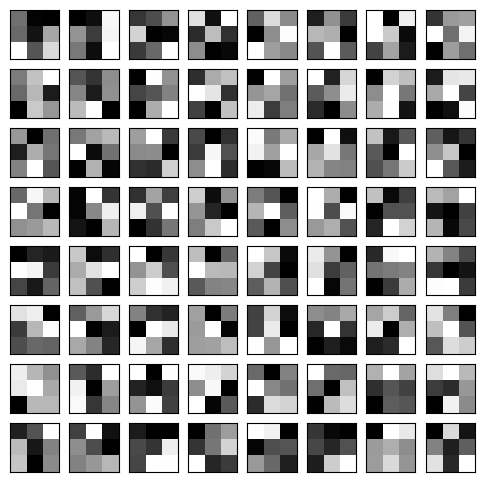

In [14]:
filter_no = 0
filters = filter_list[filter_no]
print(filter_name[filter_no])
print(filters[:,0,:,:].shape)   #(out_ch,in_cn,3,3)
square(filters[:,0,:,:].cpu().detach().numpy(), 8)

* 두번째 conv layer filter

[4]:Conv2d
torch.Size([64, 3, 3])
min[-0.06],max[0.06]


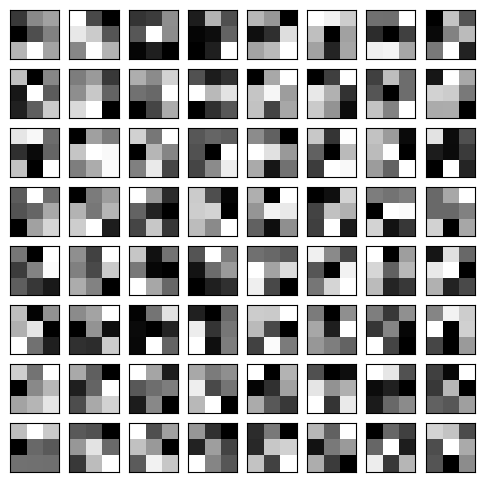

In [15]:
filter_no = 1
filters = filter_list[filter_no]
print(filter_name[filter_no])
print(filters[:,0,:,:].shape)   #(out_ch,in_cn,3,3)
square(filters[:,0,:,:].cpu().detach().numpy(), 8)

* 세번째 conv layer filter

[8]:Conv2d
torch.Size([64, 3, 3])
min[-0.07],max[0.07]


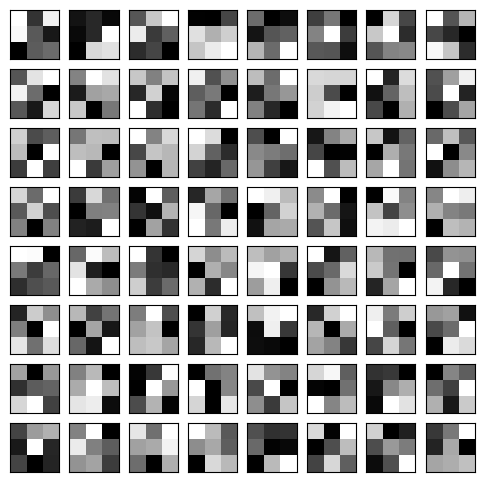

In [16]:
filter_no = 2
filters = filter_list[filter_no]
print(filter_name[filter_no])
print(filters[0,:,:,:].shape)   #(out_ch,in_cn,3,3)
square(filters[0,:,:,:].cpu().detach().numpy(), 8)

### Feature map extract model define

In [17]:
# conv layer 위치 확인
for i, layer in enumerate(model.layers):
    # check for convolutional layer
    if 'Conv' not in str(layer.__class__):
        continue #'conv'가 포함되지 않으면 skip
    # get filter weights
    filters = layer.weight
    print(f'[{i}]th layer:{layer.__class__.__name__}  {filters.shape}')

[0]th layer:Conv2d  torch.Size([64, 1, 3, 3])
[4]th layer:Conv2d  torch.Size([64, 64, 3, 3])
[8]th layer:Conv2d  torch.Size([64, 64, 3, 3])


In [18]:
class CNN_BN2_FM(nn.Module):
    def __init__(self,model):
        super(CNN_BN2_FM, self).__init__()
        self.layers = model.layers

    def forward(self, x):
        out1 = self.layers[0](x)
        out2 = self.layers[:5](x)
        out3 = self.layers[:11](x) ## ReLU 까지
        return out1, out2, out3

model_FM = CNN_BN2_FM(model)
summary(model_FM, input_size=(8, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
CNN_BN2_FM                               [8, 64, 28, 28]           --
├─Sequential: 1-1                        --                        150,282
│    └─Conv2d: 2-1                       [8, 64, 28, 28]           576
│    └─Conv2d: 2-2                       [8, 64, 28, 28]           (recursive)
│    └─BatchNorm2d: 2-3                  [8, 64, 28, 28]           128
│    └─ReLU: 2-4                         [8, 64, 28, 28]           --
│    └─MaxPool2d: 2-5                    [8, 64, 14, 14]           --
│    └─Conv2d: 2-6                       [8, 64, 14, 14]           36,928
│    └─Conv2d: 2-7                       [8, 64, 28, 28]           (recursive)
│    └─BatchNorm2d: 2-8                  [8, 64, 28, 28]           (recursive)
│    └─ReLU: 2-9                         [8, 64, 28, 28]           --
│    └─MaxPool2d: 2-10                   [8, 64, 14, 14]           --
│    └─Conv2d: 2-11                      [8, 64

In [19]:
model_FM ## summary와 다르게 model 전체 다 있음

CNN_BN2_FM(
  (layers): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=576, out_features=256, bias=True)
    (14): Linear(in_features=256, out_features=10, bi

In [ ]:
#torch.onnx.export(model_FM, torch.zeros(8, 1, 28, 28).to(device), 'model_FM.onnx')

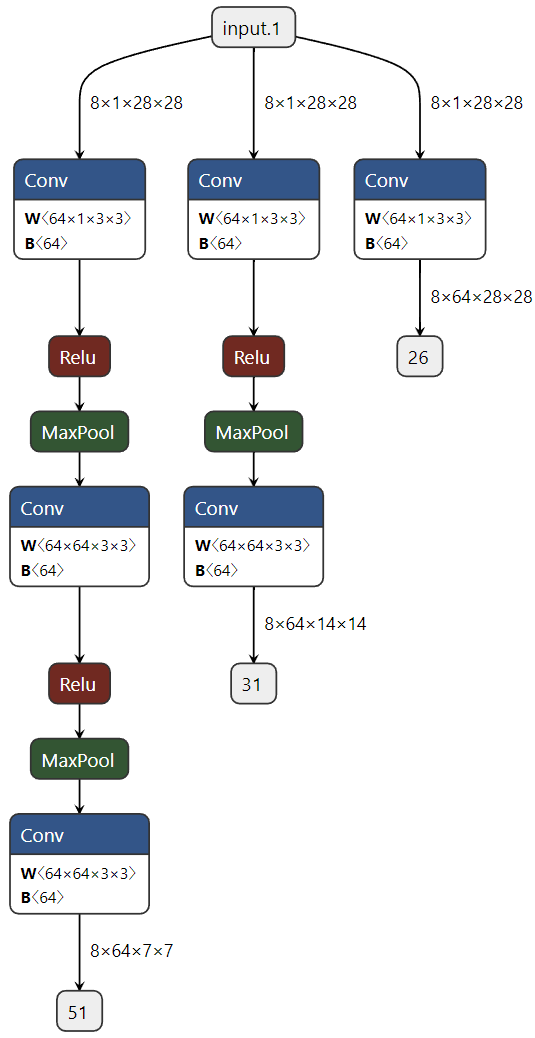

**Test imae 준비**

In [20]:
ps(test_dataset[0][0][0])

[] Shapetorch.Size([28, 28])


In [21]:
# test_dataset[i'th][0:image,1:label]
ps(test_dataset[0][0])    #(1,28,28) : 0번sample의 image
ps(test_dataset[0][0][0]) #(28,28)
print(test_dataset[0][1]) # 7        : 0번sample의 label

[] Shapetorch.Size([1, 28, 28])
[] Shapetorch.Size([28, 28])
7


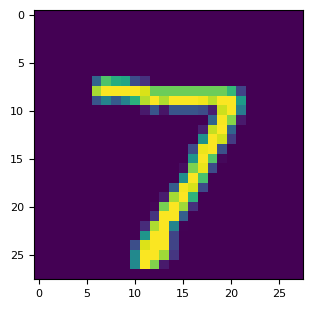

In [22]:
plt.imshow(test_dataset[0][0][0])
plt.show()

In [23]:
# Returns 3 items tuple(tensor, grad_fn)
n=0  # 첫번째 이미지를 넣고 추론하면서, feature를 반환 받음
image = test_dataset[n][0].unsqueeze(dim=0) #(1,1,28,28)<-(1,28,28)

#[(1,28,28,64),(1,14,14,64),(1,7,7,64)]
feature_maps = model_FM(image.to(device))

In [24]:
pst(feature_maps[0]) #(1,64,28,28)
pst(feature_maps[1]) #(1,64,14,14)
pst(feature_maps[2]) #(1,64,7,7)

[] Shapetorch.Size([1, 64, 28, 28]), <class 'torch.Tensor'>
[] Shapetorch.Size([1, 64, 14, 14]), <class 'torch.Tensor'>
[] Shapetorch.Size([1, 64, 7, 7]), <class 'torch.Tensor'>


#### Plot the feature maps

min[-1.15],max[1.34]


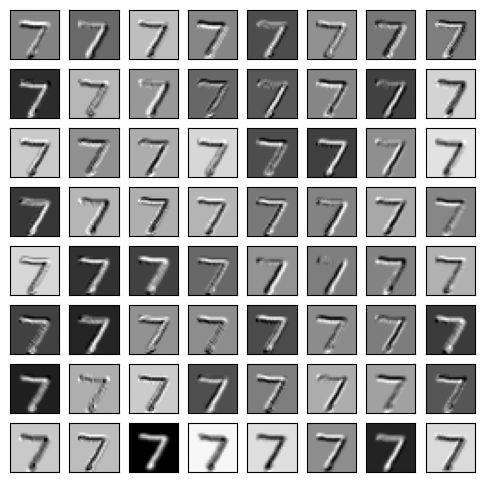

min[-6.08],max[5.99]


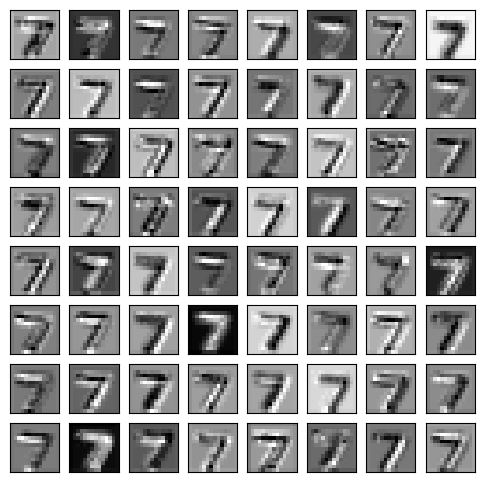

min[0.00],max[4.90]


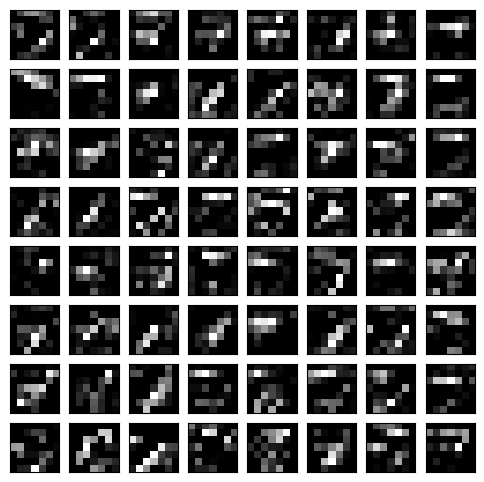

In [25]:
# 3개의 레이어가 출력한 각64개의 feature map
for i, fmap in enumerate(feature_maps):
    square(fmap.cpu().detach().numpy()[0], 8)

## **실습 과제**

#### 과제 feature map을 관찰해 보자  
##### -- Conv layer의 입력 feature를 확인해 보자  
##### -- MaxPooling layer 통과 전후의 feature map을 비교해보자
##### -- BatchNormalization layer 통과 전후의 feature map을 비교해 보자  

In [26]:
model.layers[:4]

Sequential(
  (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [27]:
class CNN_BN2_FM(L.LightningModule):
    def __init__(self,model):
        super(CNN_BN2_FM, self).__init__()
        self.layers = model.layers

    def forward(self, x):
        out1 = self.layers[0](x)
        out2 = self.layers[1](out1)
        out3 = self.layers[2](out2)
        out4 = self.layers[3](out3)
        return out1, out2, out3, out4

model_FM = CNN_BN2_FM(model)
summary(model_FM, input_size=(8, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
CNN_BN2_FM                               [8, 64, 28, 28]           --
├─Sequential: 1-1                        --                        224,394
│    └─Conv2d: 2-1                       [8, 64, 28, 28]           576
│    └─BatchNorm2d: 2-2                  [8, 64, 28, 28]           128
│    └─ReLU: 2-3                         [8, 64, 28, 28]           --
│    └─MaxPool2d: 2-4                    [8, 64, 14, 14]           --
Total params: 225,098
Trainable params: 225,098
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.61
Input size (MB): 0.03
Forward/backward pass size (MB): 6.42
Params size (MB): 0.00
Estimated Total Size (MB): 6.45

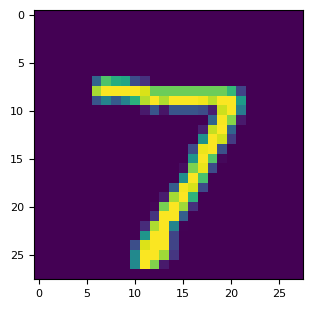

In [28]:
plt.imshow(test_dataset[0][0][0])

- Get feature maps : fm_model.predict( )

In [29]:
# Returns 3 items tuple(tensor, grad_fn)
n=0  # 첫번째 이미지를 넣고 추론하면서, feature를 반환 받음
feature_maps = model_FM(
    test_dataset[n][0].unsqueeze(dim=0).to(device)) #(1,1,28,28)<-(1,28,28)

In [30]:
pst(feature_maps[0]) # Conv2d
pst(feature_maps[1]) # BatchNorm2d
pst(feature_maps[2]) # ReLU
pst(feature_maps[3]) # MaxPool2d

[] Shapetorch.Size([1, 64, 28, 28]), <class 'torch.Tensor'>
[] Shapetorch.Size([1, 64, 28, 28]), <class 'torch.Tensor'>
[] Shapetorch.Size([1, 64, 28, 28]), <class 'torch.Tensor'>
[] Shapetorch.Size([1, 64, 14, 14]), <class 'torch.Tensor'>


#### Plot the feature maps

[0:Conv2d]:(torch.Size([64, 28, 28])), min[-1.15],max[1.34]


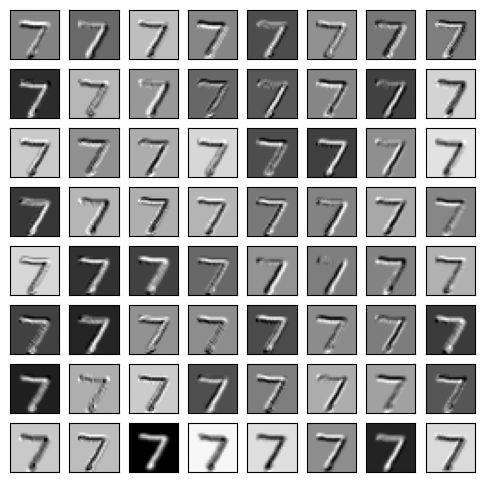

[1:BatchNorm2d]:(torch.Size([64, 28, 28])), min[-8.14],max[6.68]


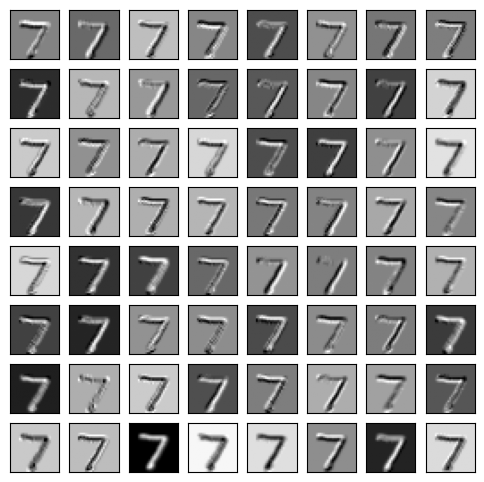

[2:ReLU]:(torch.Size([64, 28, 28])), min[0.00],max[6.68]


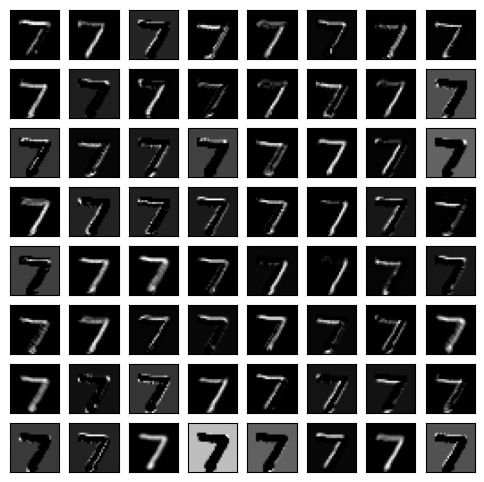

[3:MaxPool2d]:(torch.Size([64, 14, 14])), min[0.00],max[6.68]


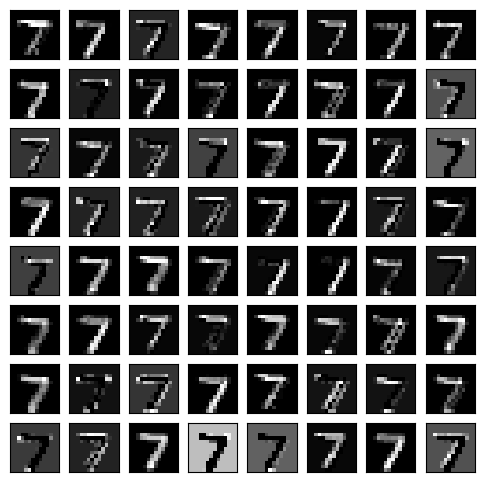

In [31]:
# 3개의 레이어가 출력한 각64개의 feature map
for i, fmap in enumerate(feature_maps):
    l_name = model_FM.layers[i].__class__.__name__
    print(f"[{i}:{l_name}]:({fmap[0].shape}), ",end="")
    square(fmap.cpu().detach().numpy()[0], 8)